# Network Science Assignment 6

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 4. November 2024

In [58]:
import matplotlib.pyplot as plt
import networkx as nx
import glob
import powerlaw
import numpy as np
from scipy.special import factorial, gammaln


In [51]:
def initialize_figure(ROWS, COLS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(5 * COLS, 5 * ROWS))
    axes = axes.flatten()
    return fig, axes

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

## Task 1

Build networks with the Barabási‑Albert model. Connect m= 3 for each new node and grow until N=
50,100,500,1000,5000, then compute some network properties. Compare them with randomized versions of
the networks.

In [27]:
# In this first part of, we generate the networks following the Barabási‑Albert model, implemented by nx. 
# N = [50, 100, 500, 1000, 5000], m = 3

N = [50, 100, 500, 1000, 5000]
m = 3

# first the original networks (seed set, plus a clique of m = 3 nodes as initial graph - as provided in the lecture notes)
ba_networks = {n: nx.barabasi_albert_graph(n, m, 100, nx.complete_graph(m)) for n in N}

# randomized version of the networks
ba_networks_random = {k: nx.algorithms.smallworld.random_reference(v.copy(), connectivity=False) for k,v in ba_networks.items()}

### Task 1.1
Compute the average clustering coefficient, assortativity, average shortest path length, and diameter.

In [28]:
# original networks
cc_original = {k: nx.average_clustering(v) for k, v in ba_networks.items()}
assortativity_original = {k: nx.degree_assortativity_coefficient(v) for k, v in ba_networks.items()}
avg_path_original = {k: nx.average_shortest_path_length(v) for k, v in ba_networks.items()}
dia_original = {k: nx.diameter(v) for k, v in ba_networks.items()}

# randomized networks
cc_rand = {k: nx.average_clustering(v) for k, v in ba_networks_random.items()}
assortativity_rand = {k: nx.degree_assortativity_coefficient(v) for k, v in ba_networks_random.items()}
avg_path_rand = {k: nx.average_shortest_path_length(v) for k, v in ba_networks_random.items()}
dia_rand = {k: nx.diameter(v) for k, v in ba_networks_random.items()}

### Task 1.2
Compare them by scatterplots with the same measures on randomized versions of the networks

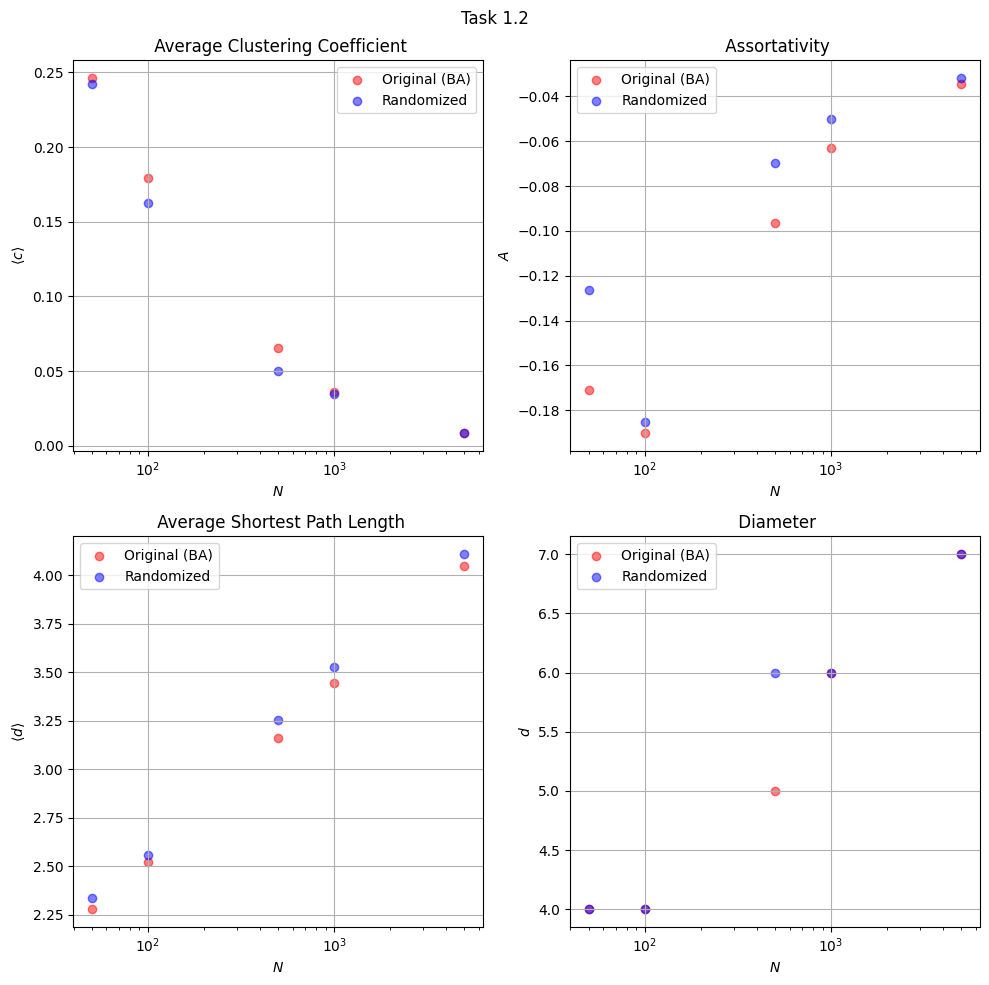

In [29]:
# adds a given set of calculated measures to a scatterplot (original vs. randomized) 
def add_to_scatter(ax, original, rand, title, x_label, y_label):
    ax.scatter(original.keys(),
               original.values(),
               color='red',
               alpha=0.5,
               label='Original (BA)')
    ax.scatter(rand.keys(),
               rand.values(),
               color='blue',
               alpha=0.5,
               label='Randomized')
    set_ax_labels(ax, x_label, y_label, title)
    ax.set_xscale('log')
    ax.legend()
    ax.grid()


labels = [
    ['Average Clustering Coefficient', '$N$', r'$\langle c \rangle$'],
    ['Assortativity', '$N$', '$A$'],
    ['Average Shortest Path Length', '$N$', r'$\langle d \rangle$'],
    ['Diameter', '$N$', '$d$']
]

original_properties = [cc_original, assortativity_original, avg_path_original, dia_original]
randomized_properties = [cc_rand, assortativity_rand, avg_path_rand, dia_rand]


fig, axes = initialize_figure(2,2)
for i, v in enumerate(original_properties):
    add_to_scatter(axes[i], v, randomized_properties[i], *labels[i])

fig.suptitle("Task 1.2")
fig.tight_layout()


### Task 1.3
Which measures are relatively unchanged by randomization? Why?

## Task 2

In [43]:
# load the data
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

### Task 1.1

Compute the exponent $\gamma$ of the power-law distribution fit $p(k) \sim k^{-\gamma}$ of the network degree distribution and the corresponding error.

#### Comments
The below code is inspired by teh original paper on the powerlaw package: 
[powerlaw: a Python package for analysis of heavy-taileddistributions](https://arxiv.org/pdf/1305.0215)


In [49]:
def powerlaw_Fit(G):
    degrees = sorted([degree for _, degree in G.degree()])
    return powerlaw.Fit(degrees)

powerlaw_Fits = [powerlaw_Fit(x) for x in data_lst]

for i, v in enumerate(powerlaw_Fits):
    print(f"{data_names[i]}: gamma={v.power_law.alpha}, sigma={v.sigma}")


Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
internet: gamma=2.112191339113011, sigma=0.0366878070312722
actors: gamma=2.1609477665039183, sigma=0.003276703809865102
macaque: gamma=17.04488902994108, sigma=4.01122225748527
flavor: gamma=16.088703066926584, sigma=1.5562808921718294


### Task 1.2 

Produce a single plot showing:
- the empirical degree distribution,
- the power‑law fit,
- the Poisson fit,
- the exponential distribution with mean value equal to ⟨k⟩.

Which distribution is more likely to describe the data?

In [59]:
# helper functions to calculate the required measures
def empirical_distribution(G):
    degrees = sorted([degree for _, degree in G.degree()])
    unique_degrees, degree_counts = np.unique(degrees, return_counts=True)
    dist = degree_counts / len(G)
    return unique_degrees, dist

def poisson_distribution(G):
    degrees = sorted([degree for _, degree in G.degree()])
    k_mean = np.mean (degrees)  
    k_vals = range(1, max(np.unique(degrees)))
    dist = []
    for k in k_vals:
        # Avoid direct exponentiation since leads to overflow encountered in scalar power
        # p_k = (k_mean**k / factorial(k)) * np.exp(-k_mean)
        p_k_log = k * np.log(k_mean) - gammaln(k + 1) - k_mean
        p_k = np.exp(p_k_log)  # Convert back
        dist.append(p_k)

    return k_vals, dist

def exponential_distribution(G):
    degrees = sorted([degree for _, degree in G.degree()])
    k_mean = np.mean (degrees)  
    k_vals = range(1, max(np.unique(degrees)))
    dist = []
    for k in k_vals:
        p_k = (1/k_mean) * np.exp(-(k/k_mean))
        dist.append(p_k)
    return k_vals, dist

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


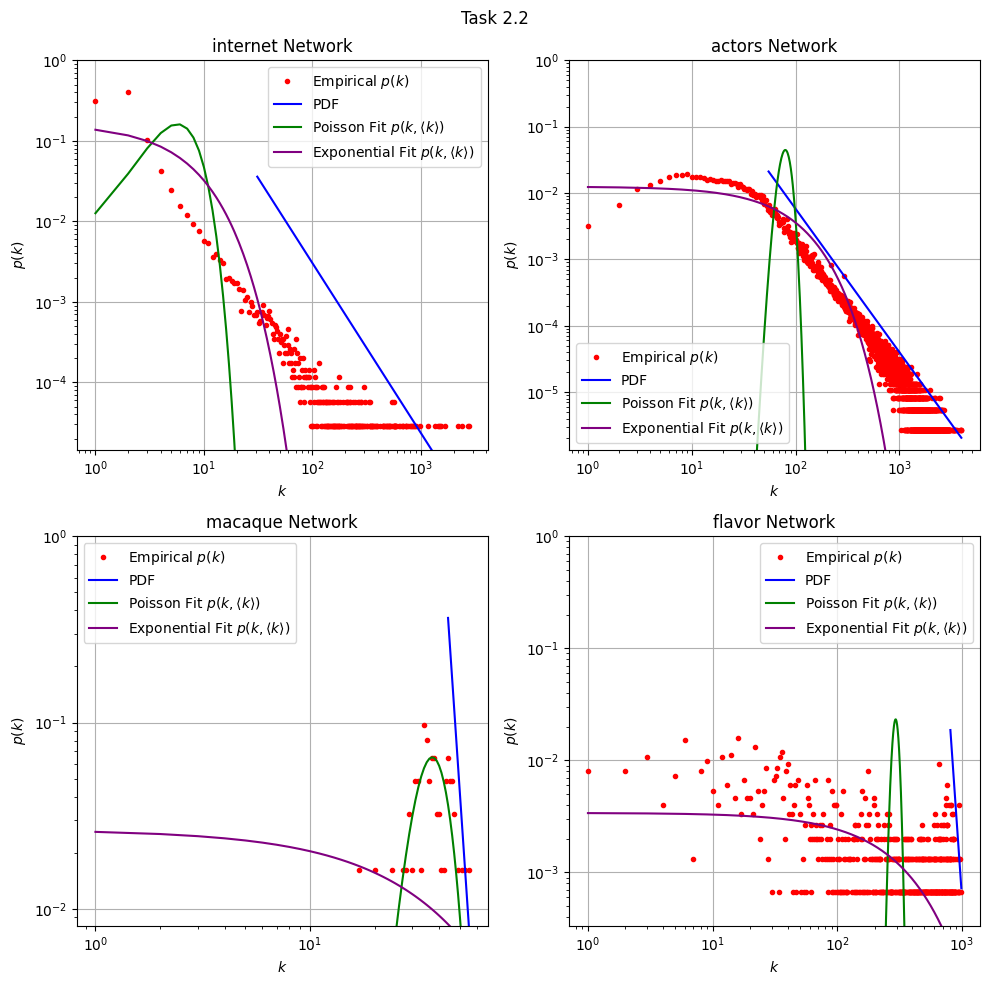

In [60]:
# create one plot per dataset
def add_to_plot(ax, G, title, log_scaled):
    unique_degrees, empirical_dist = empirical_distribution(G)
    ax.plot(unique_degrees, empirical_dist, 'o', markersize=3, color='red', label=r'Empirical $p(k)$')

    pwl_fit = powerlaw_Fit(G)
    pwl_fit.power_law.plot_pdf(color='blue', ax=axes[i], label=r'PDF')

    k_values, poisson_dist = poisson_distribution(G)
    ax.plot(k_values, poisson_dist, color='green', linewidth=1.5, label=r'Poisson Fit $p(k, \langle k \rangle)$')

    k_values, exp_dist = exponential_distribution(G)
    ax.plot(k_values, exp_dist, color='purple', linewidth=1.5, label=r'Exponential Fit $p(k, \langle k \rangle)$')

    ax.grid()
    ax.legend()
    ax.set_title(f'{title} Network')
            
            
    ax.set_ylim(min(empirical_dist) / 2, 1)

    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$p(k)$')
    ax.set_yscale('log')

fig, axes = initialize_figure(2,2)
for i, G in enumerate(data_lst):
    log_scaled = True if data_names[i] == 'macaque' else False
    add_to_plot(axes[i], G, data_names[i], log_scaled)

fig.suptitle("Task 2.2")
fig.tight_layout()